House Price Prediction Project
XYLOFY AI Internship - Week 1

Name: Roshan Manjal

# **Task 1:- Data Loaading and Exploration**



In [11]:
from google.colab import files

print("📁 Please upload your file (CSV, Excel, PDF, etc.)")

uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    print(f"✅ File uploaded successfully: {filename}")
else:
    print("❌ No file uploaded.")

📁 Please upload your file (CSV, Excel, PDF, etc.)


Saving Housing.csv to Housing (2).csv
✅ File uploaded successfully: Housing (2).csv


In [12]:
import pandas as pd
df = pd.read_csv(filename)
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [13]:
df.shape

(545, 13)

In [14]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [15]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# **Task 2:- Data Cleaning**

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [19]:
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [20]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


# **Task 3:- Model Building**

In [25]:
X = df.drop('price', axis=1)

y = df['price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 13)
(109, 13)
(436,)
(109,)


In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [29]:
pred_lr = lr.predict(X_test)

pred_lr[:5]

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.32722559, 3294646.25725955])

In [30]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [31]:
mae = mean_absolute_error(y_test, pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, pred_lr))

r2 = r2_score(y_test, pred_lr)

print("MAE =", mae)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 970043.4039201636
RMSE = 1324506.9600914386
R2 Score = 0.6529242642153184


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [33]:
pred_rf = rf.predict(X_test)

pred_rf[:5]

array([5377680.  , 7287070.  , 3747528.75, 4502120.  , 3748885.  ])

In [34]:
mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

r2_rf = r2_score(y_test, pred_rf)

print("MAE =", mae_rf)
print("RMSE =", rmse_rf)
print("R2 Score =", r2_rf)

MAE = 1021546.0353211008
RMSE = 1400565.9728553821
R2 Score = 0.611918531405699


In [35]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R2 Score': [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


# **Task 4:-  Visualization (Minimum 3 charts)**

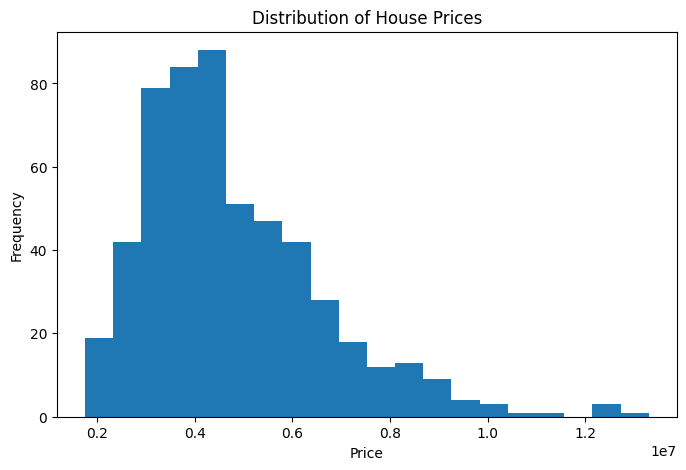

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=20)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

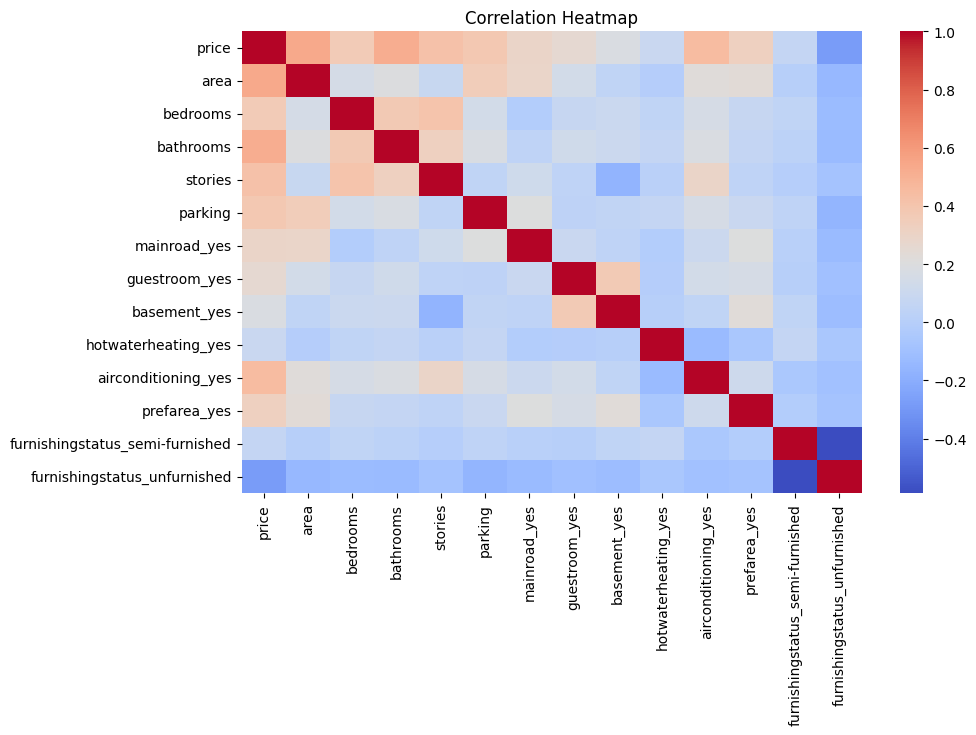

In [40]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

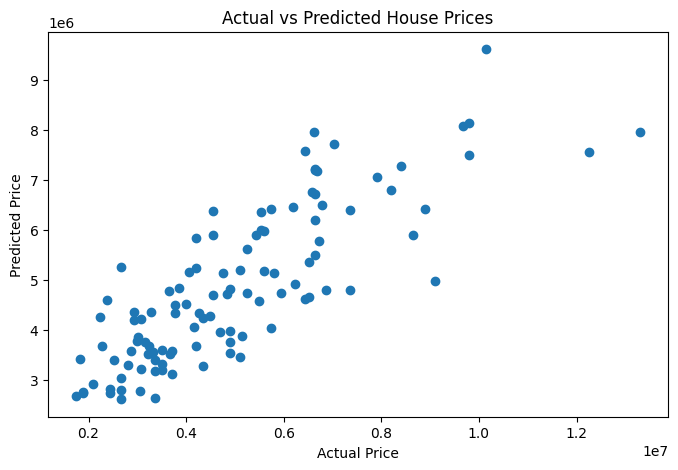

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    pred_lr
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

# **Task 5 — Insights & Summary**

Insights & Summary

The most important factors affecting house prices were area, bathrooms, and stories.

Linear Regression performed better than Random Forest with an R² Score of 0.653.

The model was able to explain approximately 65% of the variation in house prices.

One interesting observation was that some house amenities had a smaller impact on price than expected.

A real estate company can use these insights to price houses more accurately and focus on features that increase property value.